In [1]:
!pip install geopandas fiona pyogrio matplotlib numpy pandas mapclassify shapely pyproj

In [3]:
import os

# Downloaded the dataset from the Aqueduct website and imported it from a local folder
base_folder = os.path.expanduser("~/Downloads/Aqueduct40_waterrisk_download_Y2023M07D05")
for item in os.listdir(base_folder):
    print(item)

GDB
.DS_Store
CVS
Aqueduct40_README.xlsx


In [4]:
import os

# Checking the folders in the downloaded dataset
base_folder = os.path.expanduser("~/Downloads/Aqueduct40_waterrisk_download_Y2023M07D05/GDB")
for item in os.listdir(base_folder):
    print(item)

.DS_Store
Aq40_Y2023D07M05.gdb


In [5]:
import os
import fiona
import geopandas as gpd

gdb_path = os.path.expanduser(
    "~/Downloads/Aqueduct40_waterrisk_download_Y2023M07D05/GDB/Aq40_Y2023D07M05.gdb"
)

print(os.path.exists(gdb_path))  

# List all layers to confirm the exact name of the future_annual layer
print(fiona.listlayers(gdb_path))

True
['baseline_annual', 'baseline_monthly', 'future_annual']


In [6]:
demand_field = "bau50_ww_x_r"   # water demand
supply_field = "bau50_ba_x_r"   # water supply

In [7]:
gdf = gpd.read_file(gdb_path, layer="future_annual")
print(type(gdf))
print(gdf.shape)

/opt/anaconda3/envs/gis_env/lib/python3.11/site-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


<class 'geopandas.geodataframe.GeoDataFrame'>
(16395, 187)


In [8]:
# Clipping the dataset to the target site
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
australia = world[world["ADMIN"] == "Australia"]

gdf_proj = gdf.to_crs(epsg=3577)
australia_proj = australia.to_crs(epsg=3577)

gdf_au = gpd.clip(gdf_proj, australia_proj)
print(len(gdf_au))

976


In [9]:
# Classifying demand and supply into quartiles
import pandas as pd

gdf_au = gdf_au[(gdf_au[demand_field] >= 0) & (gdf_au[supply_field] >= 0)].copy()

gdf_au["demand_cls"] = pd.qcut(gdf_au[demand_field], 4, labels=[1, 2, 3, 4]).astype(int)
gdf_au["supply_cls"] = pd.qcut(gdf_au[supply_field], 4, labels=[1, 2, 3, 4]).astype(int)

gdf_au["bivar_cls"] = (gdf_au["demand_cls"] - 1) * 4 + gdf_au["supply_cls"]

In [10]:
# Building a 4×4 bivariate colour matrix
import numpy as np

def hex_to_rgb(h):
    h = h.lstrip('#')
    return np.array([int(h[i:i+2], 16) for i in (0, 2, 4)], dtype=float)

def rgb_to_hex(rgb):
    rgb = np.clip(rgb, 0, 255).astype(int)
    return '#{:02x}{:02x}{:02x}'.format(*rgb)

c_ll = hex_to_rgb("#f2e9d8")   # low demand, low supply — warm cream
c_hl = hex_to_rgb("#e8703a")   # high demand, low supply — vivid orange (high stress)
c_lh = hex_to_rgb("#5fc4d6")   # low demand, high supply — bright cyan (low stress)
c_hh = hex_to_rgb("#3d2b5f")   # high demand, high supply — deep purple

color_matrix = {}
for d in range(1, 5):
    for s in range(1, 5):
        fd, fs = (d - 1) / 3, (s - 1) / 3
        top = c_ll * (1 - fs) + c_lh * fs
        bottom = c_hl * (1 - fs) + c_hh * fs
        rgb = top * (1 - fd) + bottom * fd
        color_matrix[(d - 1) * 4 + s] = rgb_to_hex(rgb)

gdf_au["color"] = gdf_au["bivar_cls"].map(color_matrix)

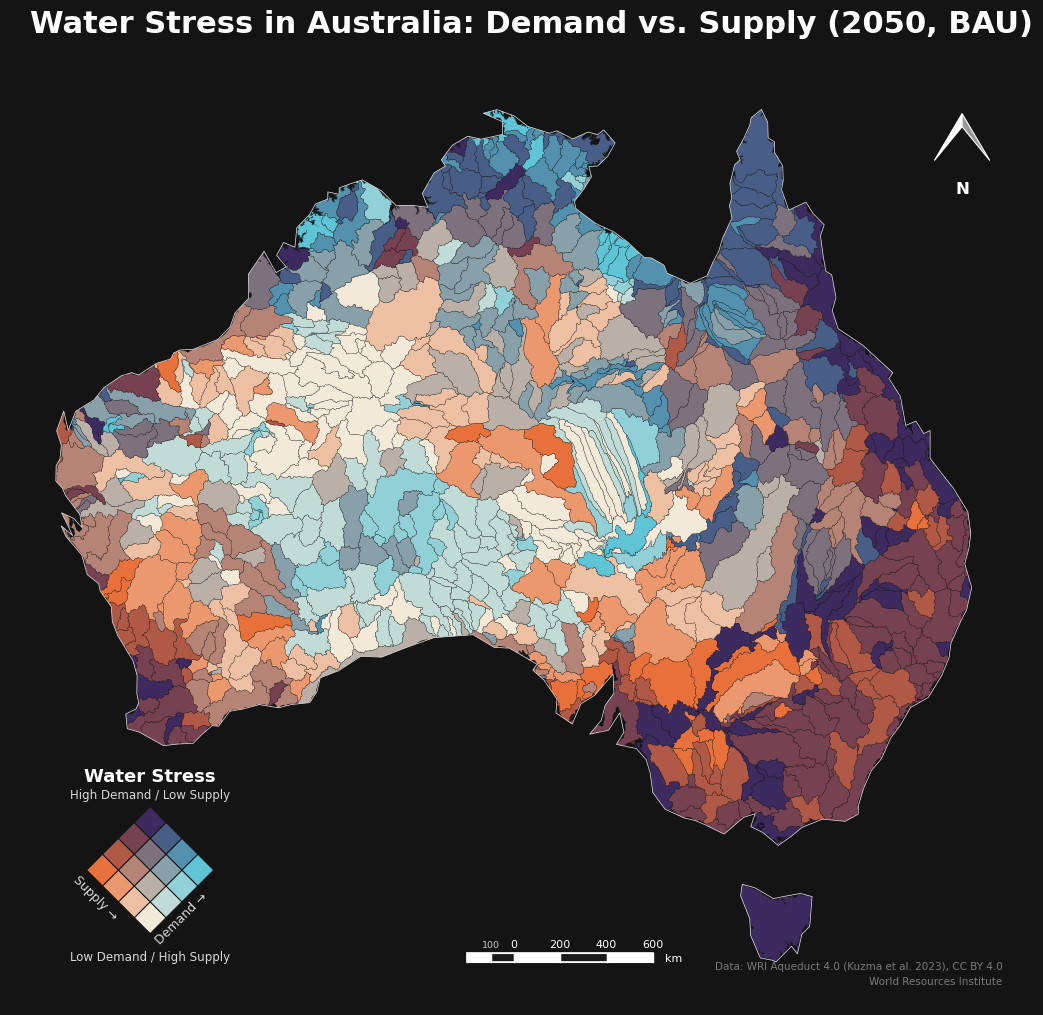

In [11]:
# Symbology, map elements and visualisation
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
from matplotlib.collections import PatchCollection
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(13, 12.5), facecolor="#141414")
ax.set_facecolor("#141414")

# --- Main map ---
gdf_au.plot(ax=ax, color=gdf_au["color"], edgecolor="#141414", linewidth=0.15)
australia_proj.boundary.plot(ax=ax, color="#e8e8e8", linewidth=0.5)

ax.set_axis_off()

# --- Title ---
ax.set_title("Water Stress in Australia: Demand vs. Supply (2050, BAU)",
             color="white", fontsize=22, fontweight="bold", pad=14, loc="left", x=0.02)

# --- North arrow ---
def draw_north_arrow(ax, x, y, size=0.045):
    """x, y = tip position in axes-fraction coords; size = arrow height in axes-fraction."""
    w = size * 0.55   
    h = size
    tip = (x, y)
    base_l = (x - w, y - h)
    base_r = (x + w, y - h)
    mid = (x, y - h * 0.28)  

    left_half = Polygon([tip, mid, base_l], closed=True,
                         facecolor="white", edgecolor="white", linewidth=0.8,
                         transform=ax.transAxes, zorder=10)
    right_half = Polygon([tip, mid, base_r], closed=True,
                          facecolor="#9a9a9a", edgecolor="white", linewidth=0.8,
                          transform=ax.transAxes, zorder=10)
    ax.add_patch(left_half)
    ax.add_patch(right_half)
    ax.text(x, y - h - 0.022, "N", transform=ax.transAxes, color="white",
            ha="center", va="top", fontsize=12, fontweight="bold", zorder=10)

draw_north_arrow(ax, x=0.945, y=0.95, size=0.05)


# --- Diamond bivariate legend ---
def rotate(pt, angle_deg, center):
    a = np.radians(angle_deg)
    ox, oy = center
    px, py = pt
    qx = ox + np.cos(a) * (px - ox) - np.sin(a) * (py - oy)
    qy = oy + np.sin(a) * (px - ox) + np.cos(a) * (py - oy)
    return qx, qy

legend_ax = inset_axes(ax, width="22%", height="20%", loc="lower left",
                        bbox_to_anchor=(0.02, 0.04, 1, 1), bbox_transform=ax.transAxes)
legend_ax.set_facecolor("none")

center = (2, 2)
patches, colors = [], []
for d in range(1, 5):
    for s in range(1, 5):
        x0, y0 = s - 1, d - 1
        corners = [(x0, y0), (x0 + 1, y0), (x0 + 1, y0 + 1), (x0, y0 + 1)]
        patches.append(Polygon([rotate(c, 45, center) for c in corners], closed=True))
        colors.append(color_matrix[(d - 1) * 4 + s])

pc = PatchCollection(patches, facecolor=colors, edgecolor="#141414", linewidth=0.7)
legend_ax.add_collection(pc)

half_diag = 4 * np.sqrt(2) / 2
legend_ax.set_xlim(center[0] - half_diag - 1.1, center[0] + half_diag + 0.9)
legend_ax.set_ylim(center[1] - half_diag - 1.2, center[1] + half_diag + 1.5)
legend_ax.set_aspect("equal")
legend_ax.set_xticks([]); legend_ax.set_yticks([])
for spine in legend_ax.spines.values():
    spine.set_visible(False)

left_corner = (center[0] - half_diag, center[1])
bottom_corner = (center[0], center[1] - half_diag)

legend_ax.text(center[0], center[1] + half_diag + 0.95, "Water Stress",
                color="white", fontsize=13, fontweight="bold", ha="center", va="bottom")
legend_ax.text(center[0], center[1] + half_diag + 0.25, "High Demand / Low Supply",
                color="#d8d8d8", fontsize=8.5, ha="center", va="bottom")
legend_ax.text(center[0], center[1] - half_diag - 0.75, "Low Demand / High Supply",
                color="#d8d8d8", fontsize=8.5, ha="center", va="top")
legend_ax.text(left_corner[0] + 0.25, left_corner[1] + 0.15,
                "  Supply →", color="#d8d8d8", fontsize=9, ha="center", va="top", rotation=-45)
legend_ax.text(bottom_corner[0] + 0.12, bottom_corner[1] - 0.55, 
               "Demand →", color="#d8d8d8", fontsize=9, ha="left", va="bottom", rotation=45)


# --- Double-bar scale ---
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
map_width_m = xmax - xmin
map_height_m = ymax - ymin

primary_km = 200          # length of the primary bar
n_primary = 3             # primary segments
n_secondary = 2           # secondary subdivisions 

seg_len_m = primary_km * 1000
bar_h = map_height_m * 0.010

x_zero = xmin + map_width_m * 0.50   # position of the "0" tick
y0 = ymin + map_height_m * 0.045

# Secondary divisions 
sec_seg_len = seg_len_m / n_secondary
for i in range(n_secondary):
    color = "white" if i % 2 == 0 else "#1a1a1a"
    ax.add_patch(Rectangle((x_zero - seg_len_m + i * sec_seg_len, y0), sec_seg_len, bar_h,
                            facecolor=color, edgecolor="white", linewidth=0.8, zorder=10))
    tick_km = int((i + 1) * primary_km / n_secondary)
    if i < n_secondary - 1:
        ax.text(x_zero - seg_len_m + (i + 1) * sec_seg_len, y0 + bar_h * 1.6, f"{tick_km}",
                color="#c8c8c8", ha="center", fontsize=6.8, zorder=10)

# Primary divisions 
for i in range(n_primary):
    color = "white" if i % 2 == 0 else "#1a1a1a"
    ax.add_patch(Rectangle((x_zero + i * seg_len_m, y0), seg_len_m, bar_h,
                            facecolor=color, edgecolor="white", linewidth=0.8, zorder=10))

for i in range(n_primary + 1):
    label_km = int(i * primary_km)
    ax.text(x_zero + i * seg_len_m, y0 + bar_h * 1.6, f"{label_km}",
            color="white", ha="center", fontsize=8, zorder=10)

ax.text(x_zero + n_primary * seg_len_m + map_width_m * 0.012, y0 + bar_h * 0.5, "km",
        color="white", ha="left", va="center", fontsize=8, zorder=10)

# --- Add a border framing the scale bar ---
total_bar_len = seg_len_m + n_primary * seg_len_m   
bar_x_start = x_zero - seg_len_m
ax.add_patch(Rectangle((bar_x_start, y0), total_bar_len, bar_h,
                        facecolor="none", edgecolor="white", linewidth=1.2, zorder=11))

tick_positions = [bar_x_start + i * sec_seg_len for i in range(n_secondary + 1)] + \
                  [x_zero + i * seg_len_m for i in range(1, n_primary + 1)]
for tx in tick_positions:
    ax.plot([tx, tx], [y0, y0 + bar_h], color="white", linewidth=1.0, zorder=11)


# --- Credits ---
ax.text(0.985, 0.02,
        "Data: WRI Aqueduct 4.0 (Kuzma et al. 2023), CC BY 4.0\nWorld Resources Institute",
        transform=ax.transAxes, color="#7a7a7a", fontsize=7.5, ha="right", va="bottom",
        linespacing=1.6)

# Final visualisation and importing
plt.savefig("australia_water_stress_map.jpg", dpi=500,
            facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()